In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Read the data
df = pd.read_csv('prod.csv')  # Adjust the path according to your file

# Select only the important columns
df_clean = df[["order_number", "product_name", "quantity"]]  # quantity is optional

In [ ]:
df.head()

,order_number,product_key,customer_key,order_date,shipping_date,due_date,sales_amount,quantity,price,product_key.1,product_id,product_number,product_name,category_id,category,subcategory,maintenance,cost,product_line,start_date
0,SO43697,20,10769,12/29/2010,1/5/2011,1/10/2011,3578,1,3578,20,310,BK-R93R-62,Road-150 Red- 62,BI_RB,Bikes,Road Bikes,Yes,2171,Road,7/1/2011
1,SO43698,9,17390,12/29/2010,1/5/2011,1/10/2011,3400,1,3400,9,346,BK-M82S-44,Mountain-100 Silver- 44,BI_MB,Bikes,Mountain Bikes,Yes,1912,Mountain,7/1/2011
2,SO43699,9,14864,12/29/2010,1/5/2011,1/10/2011,3400,1,3400,9,346,BK-M82S-44,Mountain-100 Silver- 44,BI_MB,Bikes,Mountain Bikes,Yes,1912,Mountain,7/1/2011
3,SO43700,41,3502,12/29/2010,1/5/2011,1/10/2011,699,1,699,41,337,BK-R50B-62,Road-650 Black- 62,BI_RB,Bikes,Road Bikes,Yes,487,Road,7/1/2012
4,SO43701,9,4,12/29/2010,1/5/2011,1/10/2011,3400,1,3400,9,346,BK-M82S-44,Mountain-100 Silver- 44,BI_MB,Bikes,Mountain Bikes,Yes,1912,Mountain,7/1/2011


In [ ]:
df_clean.head()

,order_number,product_name,quantity
0,SO43697,Road-150 Red- 62,1
1,SO43698,Mountain-100 Silver- 44,1
2,SO43699,Mountain-100 Silver- 44,1
3,SO43700,Road-650 Black- 62,1
4,SO43701,Mountain-100 Silver- 44,1


In [ ]:
data = df_clean.copy()
data.head()

,order_number,product_name,quantity
0,SO43697,Road-150 Red- 62,1
1,SO43698,Mountain-100 Silver- 44,1
2,SO43699,Mountain-100 Silver- 44,1
3,SO43700,Road-650 Black- 62,1
4,SO43701,Mountain-100 Silver- 44,1


In [ ]:
print("\n=== Top 10 Best-Selling Products ===")
top_products = df_clean["product_name"].value_counts().head(10)
print(top_products)

print("\n=== Basket Size Statistics ===")
basket_stats = df_clean.groupby("order_number")["product_name"].nunique().describe()
print(basket_stats)

print("\n=== Average Quantity per Product (Top 10) ===")
avg_quantity = df_clean.groupby("product_name")["quantity"].mean().sort_values(ascending=False).head(10)
print(avg_quantity)



=== Top 10 Best-Selling Products ===
product_name
Water Bottle - 30 oz.      4244
Patch Kit/8 Patches        3191
Mountain Tire Tube         3095
Road Tire Tube             2376
Sport-100 Helmet- Red      2230
AWC Logo Cap               2190
Sport-100 Helmet- Blue     2125
Fender Set - Mountain      2121
Sport-100 Helmet- Black    2085
Mountain Bottle Cage       2025
Name: count, dtype: int64

=== Basket Size Statistics ===
count    27659.000000
mean         2.183665
std          1.134096
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: product_name, dtype: float64

=== Average Quantity per Product (Top 10) ===
product_name
Classic Vest- S                1.017857
Mountain Bottle Cage           1.004444
Long-Sleeve Logo Jersey- XL    1.002421
LL Mountain Tire               1.002320
Long-Sleeve Logo Jersey- L     1.002212
Water Bottle - 30 oz.          1.001178
Bike Wash - Dissolver          1.001101
HL Mountain Tire    

In [ ]:
from os import replace
data.drop('quantity',axis=1,inplace = True)
data.head()

,order_number,product_name
0,SO43697,Road-150 Red- 62
1,SO43698,Mountain-100 Silver- 44
2,SO43699,Mountain-100 Silver- 44
3,SO43700,Road-650 Black- 62
4,SO43701,Mountain-100 Silver- 44


In [ ]:
from itertools import combinations
from collections import Counter

# Initialize a counter to store product pair frequencies
basket_combos = Counter()

# Loop through each unique order
for order in data["order_number"].unique():
    # Get all unique products purchased in this order
    products = data[df["order_number"] == order]["product_name"].unique()

    # Generate all possible 2-product combinations within the order
    basket_combos.update(combinations(products, 2))

# Show the top 10 most common product pairs
basket_combos.most_common(10)

[(('Mountain Bottle Cage', 'Water Bottle - 30 oz.'), 1267),
 (('Road Bottle Cage', 'Water Bottle - 30 oz.'), 932),
 (('Mountain Tire Tube', 'Patch Kit/8 Patches'), 785),
 (('Touring Tire', 'Touring Tire Tube'), 605),
 (('Road Tire Tube', 'Patch Kit/8 Patches'), 589),
 (('Water Bottle - 30 oz.', 'Road Bottle Cage'), 589),
 (('HL Mountain Tire', 'Mountain Tire Tube'), 556),
 (('Water Bottle - 30 oz.', 'AWC Logo Cap'), 522),
 (('ML Mountain Tire', 'Mountain Tire Tube'), 459),
 (('Mountain Tire Tube', 'Sport-100 Helmet- Black'), 453)]

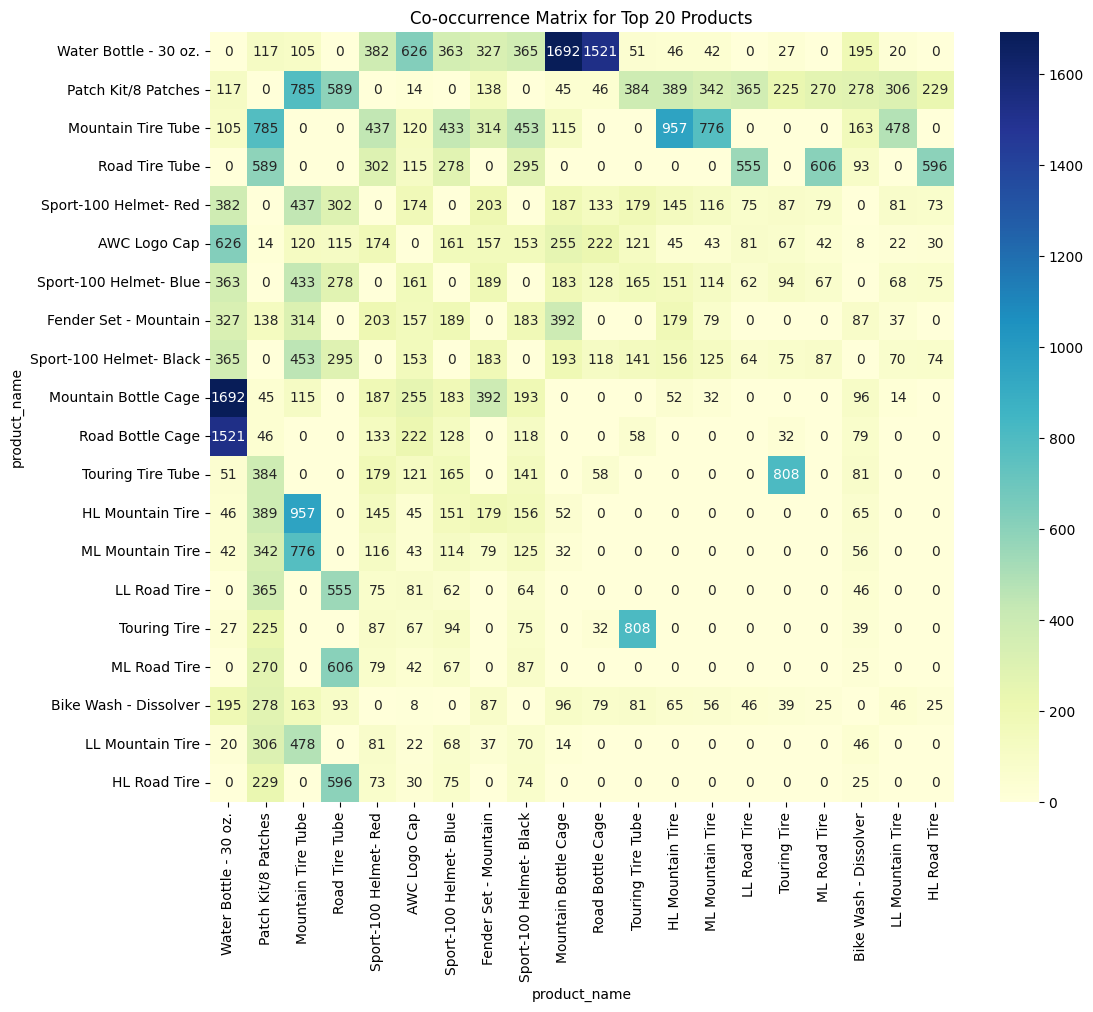

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter


# Select top 20 selling products
top_products = df["product_name"].value_counts().head(20).index
df_top = df[df["product_name"].isin(top_products)]

# Create a list of baskets for each order
order_groups = df_top.groupby("order_number")["product_name"].apply(list)

# Calculate co-occurrence
co_occurrence = pd.DataFrame(0, index=top_products, columns=top_products)

for basket in order_groups:
    for item1, item2 in combinations(basket, 2):
        co_occurrence.loc[item1, item2] += 1
        co_occurrence.loc[item2, item1] += 1

# Color the matrix
plt.figure(figsize=(12,10))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Co-occurrence Matrix for Top 20 Products")
plt.show()

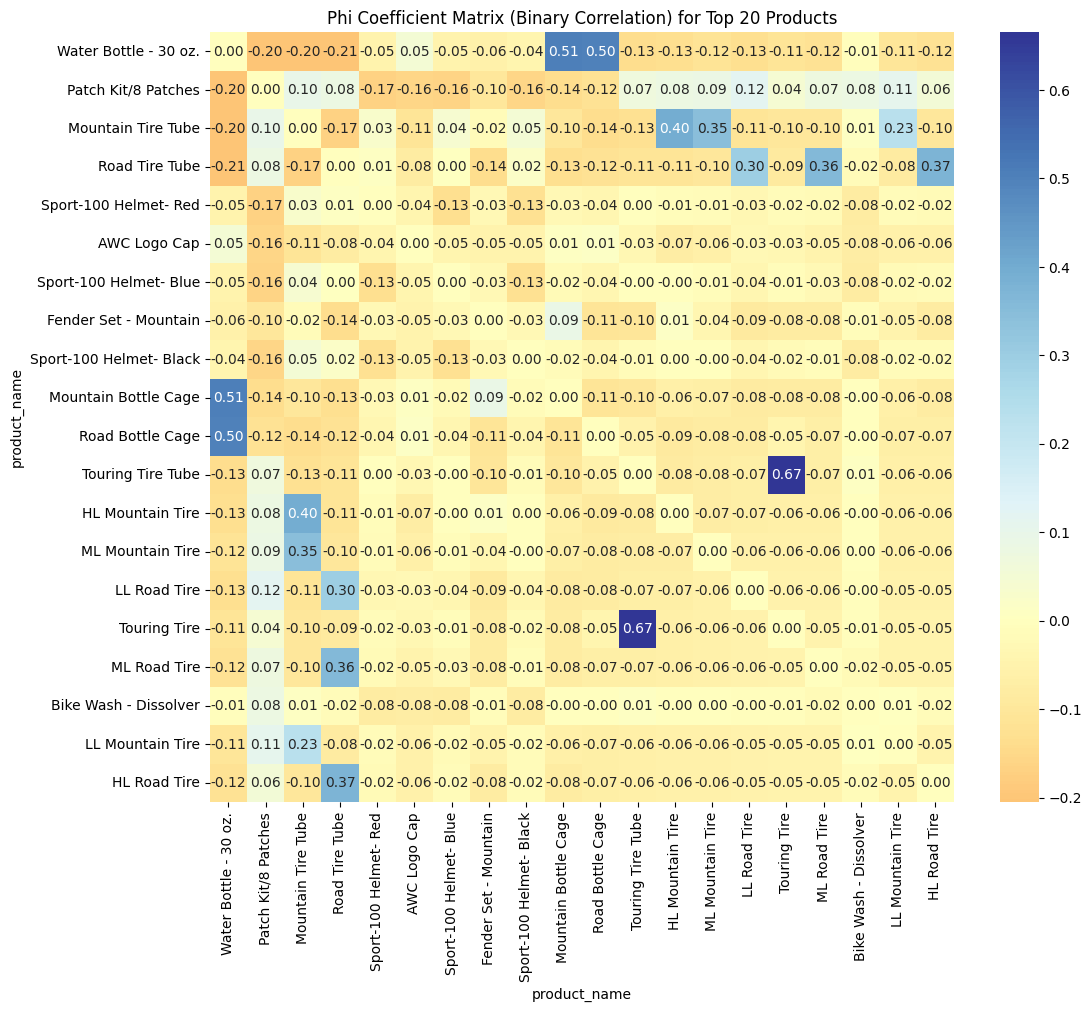

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import numpy as np

# Select top 20 selling products
top_products = df["product_name"].value_counts().head(20).index
df_top = df[df["product_name"].isin(top_products)]

# Create basket-product matrix (rows: orders, columns: products, 1 if purchased, 0 otherwise)
order_groups = df_top.groupby("order_number")["product_name"].apply(list)
basket_matrix = pd.DataFrame(0, index=order_groups.index, columns=top_products)

for order_num, products in order_groups.items():
    basket_matrix.loc[order_num, products] = 1

# Initialize phi coefficient matrix
phi_matrix = pd.DataFrame(0, index=top_products, columns=top_products, dtype=float)

# Compute phi coefficient for each pair of products
for product1, product2 in combinations(top_products, 2):
    A = basket_matrix[product1]
    B = basket_matrix[product2]

    n11 = ((A == 1) & (B == 1)).sum()
    n10 = ((A == 1) & (B == 0)).sum()
    n01 = ((A == 0) & (B == 1)).sum()
    n00 = ((A == 0) & (B == 0)).sum()

    numerator = n11 * n00 - n10 * n01
    denominator = np.sqrt((n11 + n10)*(n01 + n00)*(n11 + n01)*(n10 + n00))

    phi = numerator / denominator if denominator != 0 else 0

    phi_matrix.loc[product1, product2] = phi
    phi_matrix.loc[product2, product1] = phi  # symmetric

# Plot phi coefficient heatmap
plt.figure(figsize=(12,10))
sns.heatmap(phi_matrix, annot=True, fmt=".2f", cmap="RdYlBu", center=0)
plt.title("Phi Coefficient Matrix (Binary Correlation) for Top 20 Products")
plt.show()

In [ ]:
# Calculate the support for each product: the proportion of orders that include each product
support = df["product_name"].value_counts() / df["order_number"].nunique()
print(support.head(10))


product_name
Water Bottle - 30 oz.      0.153440
Patch Kit/8 Patches        0.115369
Mountain Tire Tube         0.111898
Road Tire Tube             0.085903
Sport-100 Helmet- Red      0.080625
AWC Logo Cap               0.079179
Sport-100 Helmet- Blue     0.076829
Fender Set - Mountain      0.076684
Sport-100 Helmet- Black    0.075382
Mountain Bottle Cage       0.073213
Name: count, dtype: float64


In [ ]:
orders_before = df["order_number"].nunique()
products_before = df["product_name"].nunique()
basket_sizes_before = df.groupby("order_number")["product_name"].nunique().describe()

print("Before cleaning:")
print("Number of orders:", orders_before)
print("Number of products:", products_before)
print("Basket size statistics:")
print(basket_sizes_before)
print("\n" + "-"*50 + "\n")

# --- Data Cleaning ---
df["product_name"] = df["product_name"].str.strip().str.replace(r'\.+$', '', regex=True)
product_counts = df["product_name"].value_counts()
support = product_counts / df["order_number"].nunique()
min_support_threshold = 0.01
frequent_products = support[support >= min_support_threshold].index
df_clean = df[df["product_name"].isin(frequent_products)]
df_clean = df_clean.groupby("order_number").filter(lambda x: len(x) > 0)

# --- Statistics after cleaning ---
orders_after = df_clean["order_number"].nunique()
products_after = df_clean["product_name"].nunique()
basket_sizes_after = df_clean.groupby("order_number")["product_name"].nunique().describe()

print("After cleaning:")
print("Number of orders:", orders_after)
print("Number of products:", products_after)
print("Basket size statistics:")
print(basket_sizes_after)

Before cleaning:
Number of orders: 27659
Number of products: 130
Basket size statistics:
count    27659.000000
mean         2.183665
std          1.134096
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: product_name, dtype: float64

--------------------------------------------------

After cleaning:
Number of orders: 24814
Number of products: 57
Basket size statistics:
count    24814.000000
mean         2.102603
std          1.082774
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          8.000000
Name: product_name, dtype: float64


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from tabulate import tabulate  # Library to display tables in a formatted style

# --- Convert data to a transaction matrix ---
# Each row = order_number, each column = product, value = 1 if product is in order, 0 otherwise
basket = df_clean.groupby(['order_number', 'product_name'])['product_name'] \
                 .count().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

# --- Extract frequent itemsets using Apriori ---
# min_support=0.01 means we keep itemsets that appear in at least 1% of orders
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

# --- Generate association rules ---
# metric="lift" and min_threshold=1.0 filters rules with lift >= 1
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# --- Keep only the essential columns ---
rules_basic = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# --- Convert frozensets to readable strings ---
rules_basic['antecedents'] = rules_basic['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_basic['consequents'] = rules_basic['consequents'].apply(lambda x: ', '.join(list(x)))

# --- Sort rules by descending lift ---
rules_basic = rules_basic.sort_values('lift', ascending=False)

# --- Display top 10 rules in a nicely formatted table using tabulate ---
print(tabulate(rules_basic.head(10), headers='keys', tablefmt='fancy_grid', showindex=False))


╒═════════════════════════════════════════════╤═════════════════════════════════════════════╤═══════════╤══════════════╤══════════╕
│ antecedents                                 │ consequents                                 │   support │   confidence │     lift │
╞═════════════════════════════════════════════╪═════════════════════════════════════════════╪═══════════╪══════════════╪══════════╡
│ Touring Tire Tube                           │ Touring Tire                                │ 0.0325623 │     0.543011 │ 14.411   │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼───────────┼──────────────┼──────────┤
│ Touring Tire                                │ Touring Tire Tube                           │ 0.0325623 │     0.864171 │ 14.411   │
├─────────────────────────────────────────────┼─────────────────────────────────────────────┼───────────┼──────────────┼──────────┤
│ Fender Set - Mountain, Water Bottle - 30 oz │ Mountain Bottle Cage        